# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 77     |  |
| :-------------|:-------------|
| Tahlia van den Berg | 6399991 |
| Ole Doekes| 6489028 |

In [ ]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
from scipy.optimize import curve_fit
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

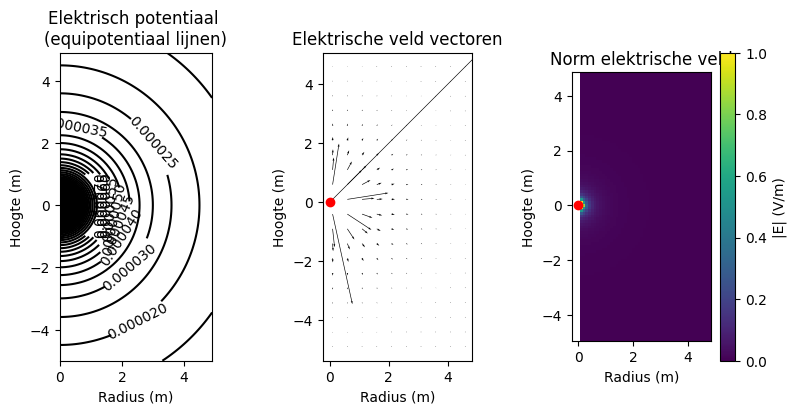

In [3]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

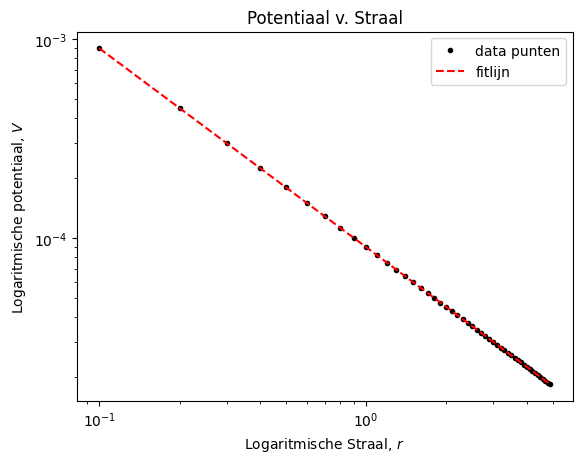

De exponent van de straal die de potentiaal van de puntlading beschrijft: -1.0


In [4]:
z_0_index = find_idx_nearest(z, 0)
z_0 = z[z_0_index]

potentiaal = V[z_0_index, :][1:] #slicing potential where the z_axis is equal to zero, for all values great than zero. 
log_potentiaal = np.log(potentiaal) #log scaling the potential
straal =r[1:]  #slicing the radius array for all values greater than zero
log_straal = np.log(straal) #log scaling the radius


def potentiaal_fit(r, a, n):
    return a * (r**n)

popt, pcov = curve_fit(potentiaal_fit, straal, potentiaal)
a = popt[0]
n = popt[1]

x_test = np.linspace(min(straal), max(straal), 1000)
y_test = potentiaal_fit(x_test, *popt)

plt.figure()
plt.plot(straal, potentiaal, 'k.', label = "data punten")
plt.plot(x_test, y_test, 'r--', label = "fitlijn")
plt.title('Potentiaal v. Straal')
plt.ylabel('Logaritmische potentiaal, $V$')
plt.xlabel('Logaritmische Straal, $r$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

print("De exponent van de straal die de potentiaal van de puntlading beschrijft:", np.round(n, 3))

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

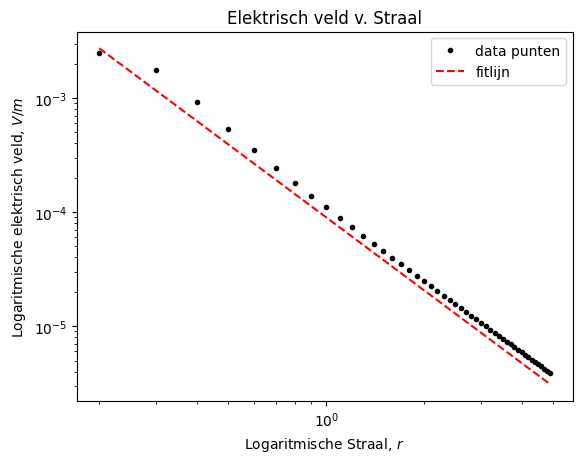

De exponent van de straal die de elektrisch veld van de puntlading beschrijft: -2.12


In [5]:
Elektrisch_veld = Er[z_0_index,:] #slicing electrical field where the z_axis is equal to zero, for all values great than zero.
Straal = straal[1:] #slicing the radius where the e-field is sliced for same length arrays
k = 1 / (4*np.pi*epsilon0) #creating the coefficient of Coulomb's constant

def E_veld(r, n):
    return k * charge_one_point * (r**n)

popt, pcov = curve_fit(E_veld, Straal, Elektrisch_veld)
straal_exp = popt[0]

x_fit = np.linspace(min(Straal), max(straal), 1000)
y_fit = E_veld(x_fit, *popt)

plt.figure()
plt.plot(Straal, Elektrisch_veld, 'k.', label = "data punten")
plt.plot(x_fit, y_fit, 'r--', label = "fitlijn")
plt.title('Elektrisch veld v. Straal')
plt.xlabel('Logaritmische Straal, $r$')
plt.ylabel('Logaritmische elektrisch veld, $V/m$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

print("De exponent van de straal die de elektrisch veld van de puntlading beschrijft:", np.round(straal_exp, 3))

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [6]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

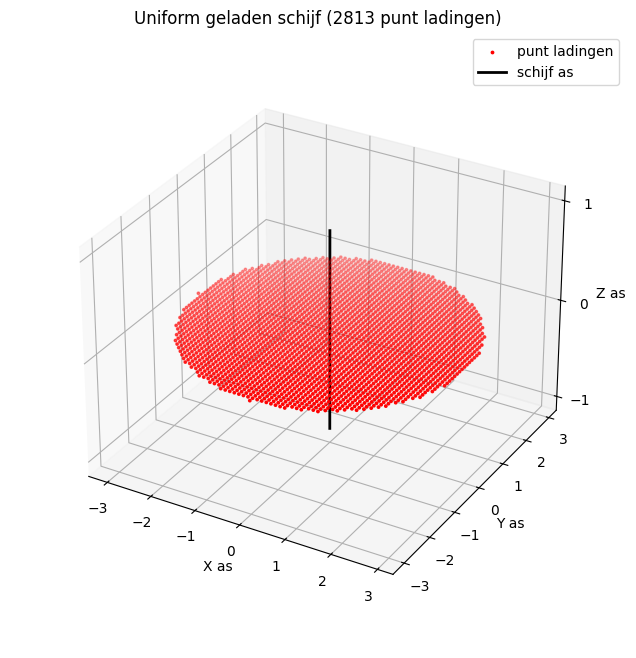

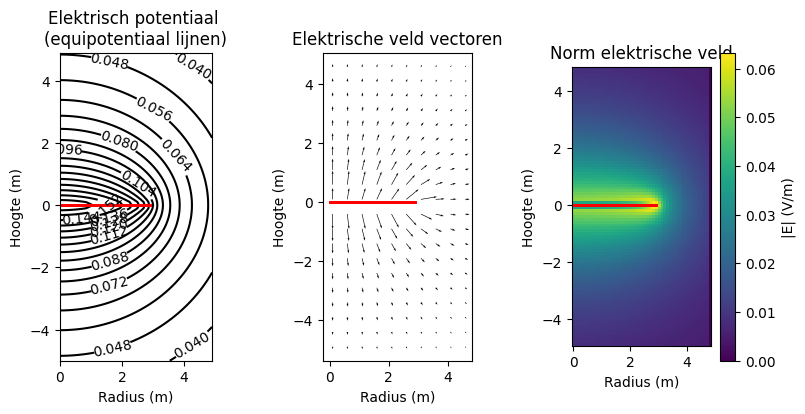

In [7]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius variable is de straal van de schijf. Wanner die naar nul gaat bestaat er geen geladen schijf meer, daardoor word de elektrisch veld ook verwaarloosd. 
2. Grid step is hoe vaak de schijf gemeten word. Dit hept met resolutie, en nauwkeuriger metingen voor bvd exponenten. 
3. z_coord_disk heeft de hoogte van de schijf op de z-as verandert.  


#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [8]:
lading = number_point_charges_on_disk * charge_one_point
oppervlak = np.pi * disk_radius**2

sigma = lading / oppervlak

print("De ladings dichtheid van de schijf is:", np.round(sigma, 16), "C/m^2")

De ladings dichtheid van de schijf is: 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

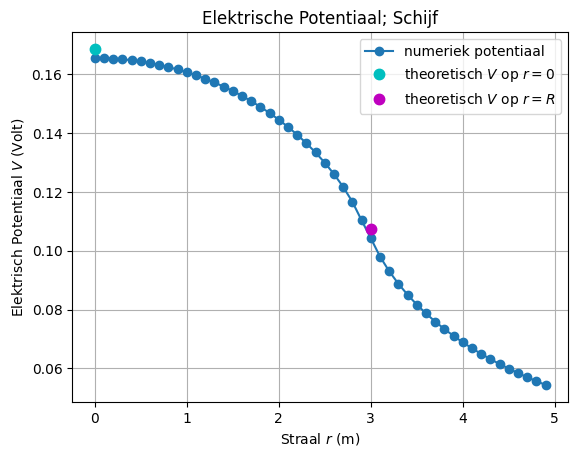

In [9]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(z, 0)

V_0 = sigma * disk_radius / (2 * epsilon0) # potentiaal op r = 0
disk_V = V[idx_z_zero, :] # potentiaal langs de r-as
V_R = 4 * k * sigma * disk_radius # potentiaal op de straal van de schijf
r_R = disk_radius # straal van de schijf

plt.title("Elektrische Potentiaal; Schijf")
plt.plot(r, disk_V, "o-", label="numeriek potentiaal") 
plt.plot(0, V_0, "c.", markersize=15, label="theoretisch $V$ op $r=0$")
plt.plot(r_R, V_R, "m.", markersize=15, label="theoretisch $V$ op $r=R$")

plt.legend()
plt.xlabel("Straal $r$ (m)")
plt.ylabel("Elektrisch Potentiaal $V$ (Volt)")
plt.grid(True)
plt.show()



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


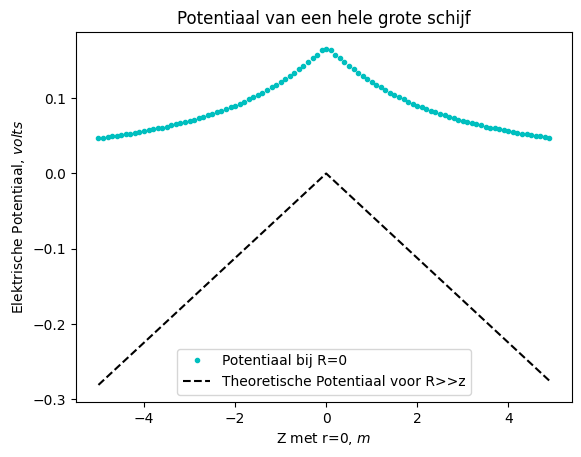

In [10]:
R_max = max(z) * 10000 #een straal creeen veel groter dan z
V_R0 = V[:,find_idx_nearest(r, 0)] #numeriek potential van array pakken bij r=0

def V_GS(z, R):
    return sigma * (R - np.abs(z)) / (2 * epsilon0)

V_GS_shifted = V_GS(z, R_max) - V_GS(z, R_max)[idx_z_zero] #Theoretisch potential naar beneden verschuiven omdat R>>Z niet goed van de grafiek te lezen is. 

plt.figure()
plt.plot(z, V_R0, 'c.', label = "Potentiaal bij R=0")
plt.plot(z, V_GS_shifted, 'k--', label = "Theoretische Potentiaal voor R>>z")
plt.xlabel("Z met r=0, $m$")
plt.ylabel("Elektrische Potentiaal, $volts$")
plt.title("Potentiaal van een hele grote schijf")
plt.legend()
plt.savefig("vraag_2d.png")
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

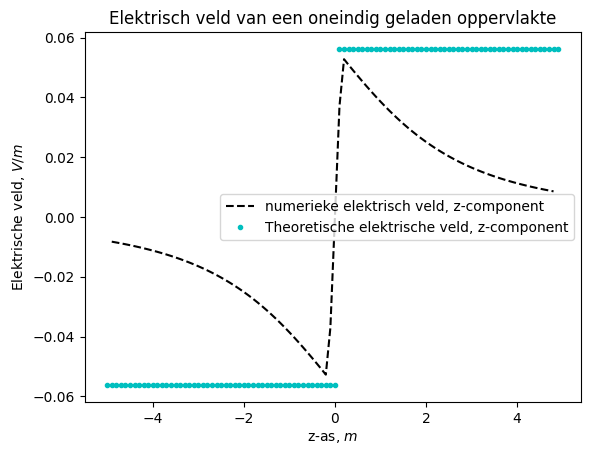

In [11]:
Ez_r0 = Ez[:, find_idx_nearest(r, 0)] #slicing the z component of the electric field to take only where r=0
z_r0 = z[1:-1] #slicing the z-array since "finite difference" method removes first and last digits
E_field = (sigma / (2 * epsilon0)) * np.sign(z) # multiplying by the \pm z ti get rid of the abs value brackets from E

plt.figure()
plt.plot(z_r0, Ez_r0, 'k--', label = "numerieke elektrisch veld, z-component")
plt.plot(z, E_field, 'c.', label = "Theoretische elektrische veld, z-component")
plt.title("Elektrisch veld van een oneindig geladen oppervlakte")
plt.xlabel("z-as, $m$")
plt.ylabel("Elektrische veld, $V/m$")
plt.legend()
plt.savefig("Vraag_2e.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Dicht bij beide oppervlakten. Daar worden de theoretische waardes allebei heel vergelijkbaar beschreven. Het veld van de oneindige plaat is $\frac{\sigma}{2 \epsilon_0}$, en de schijf is $\frac{\sigma}{2 \epsilon_0} \cdot (1 - \frac{z}{\sqrt{z^2+R^2}})$. Als $z << R$ dan is de schijfveld dezelfde waarden als de oneindige oppervlaktveld. 
2. In de plot is te zien dat het numerieke veld van de schijf afneemt wanneer z groter wordt. Dit komt doordat de schijf een eindige straal heeft en de veldlijnen zich spreiden. Daardoor wordt het veld zwakker op grotere afstand. Voor de oneindige plaat blijft het veld constant, omdat de veldlijnen overal parallel blijven. Daarom zijn de theoretische lijnen horizontaal in de grafiek 


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

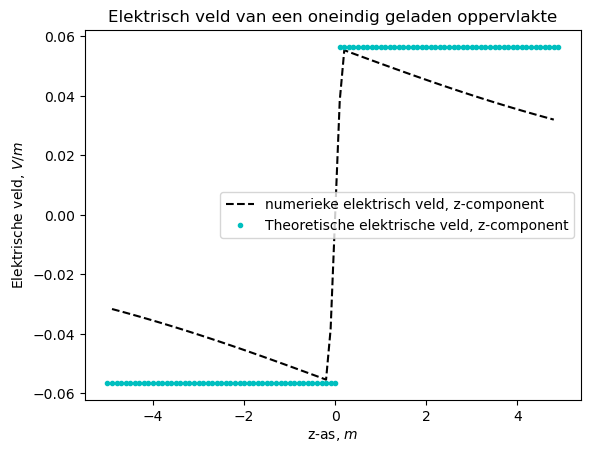

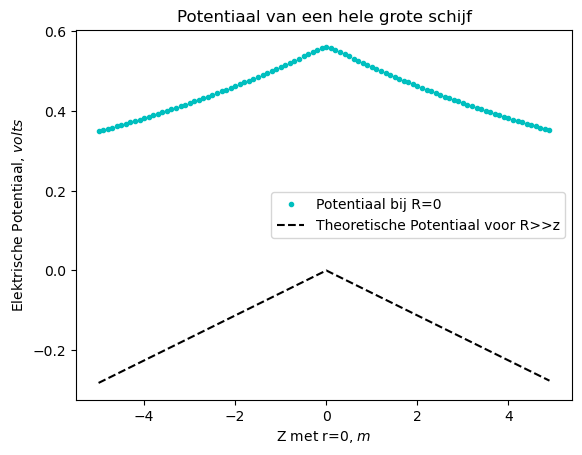

In [12]:
from IPython.display import display, Image
display(Image(filename='figures/vraag_2e_2.png'))
display(Image(filename='figures/vraag_2d_2.png'))

##### Antwoorden 2g

Het elektrische veld dat uit de schijf komt ziet er minder gekrommt uit met een straal die ongeveer 3 keer zo groot is. Dit komt omdat de schijf zich een beetje meer als oneindig grote oppervlak gedraagt. Dan zien de veld lijnen er meer consistant uit, het is bijna zoals "in zoomen" op de normale maat schijf.  

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

$0.10 = [1 - \frac{z}{\sqrt{R^2 + z^2}}]$

$0.90 \cdot \sqrt{R^2 + z^2} = z$

$0.90^2 (R^2 + z^2) = z^2$

$0.81R^2 = 0.19z^2$

$\frac{0.81}{0.19}R^2 = z^2$

$z = \pm \frac{0.90}{\sqrt{0.19}}R$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

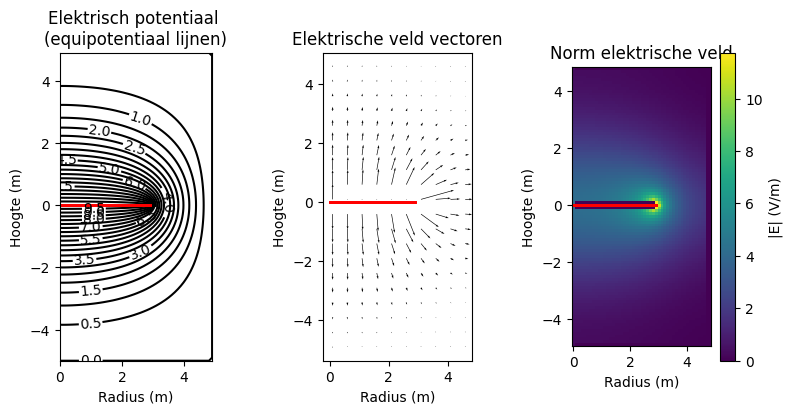

In [13]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

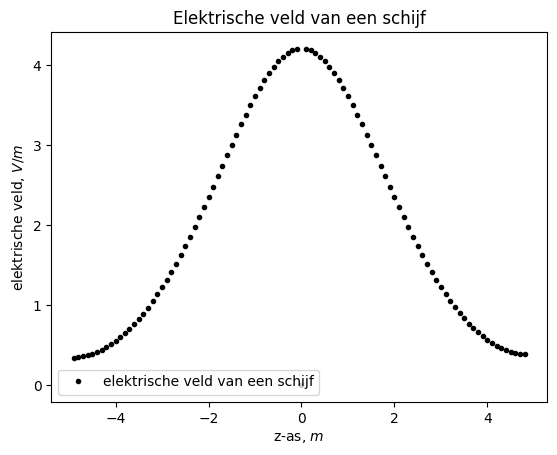

De norm van het elektrische veld dicht bij de midden van de schijf: 0.0 V/m


In [14]:
idx_R0 = find_idx_nearest(r_for_E, 0) #finding on which part of the array the radius of the disk is 0.

E_as = normE[:, idx_R0] #slicing the norm of the electric field for that part of the radius

plt.figure()
plt.plot(z_for_E, E_as, 'k.', label = "elektrische veld van een schijf")
plt.xlabel("z-as, $m$")
plt.ylabel("elektrische veld, $V/m$")
plt.title("Elektrische veld van een schijf")
plt.legend()
plt.show()

E_center = normE[find_idx_nearest(z_for_E, z_pos_disk1), idx_R0] #slicing the array of the norm of the e-field where the radius is close to zero and the z-axis location of the disk 

print("De norm van het elektrische veld dicht bij de midden van de schijf:", np.round(E_center, 3) , "V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

$E_{buiten} - E_{binnen} = \frac{\sigma}{\epsilon_0}$

In [15]:
idx_z_buiten = find_idx_nearest(z_for_E, z_pos_disk1 + grid_step) # finding the index just outside the conducting disk

E_binnen = 0
E_buiten = normE[idx_z_buiten, idx_R0] # slicing the norm of the electric field just outside the disk

sigma = epsilon0 * (E_buiten - E_binnen) # calculating the surface charge density using Gauss's law

idx_r_midden = find_idx_nearest(r_for_E, 0) # finding the index for the radial position in the center

print("De benadering van de oppervlakte lading in het midden van de schijf:", np.round(sigma, 12), "C/m^2")

De benadering van de oppervlakte lading in het midden van de schijf: 3.7e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


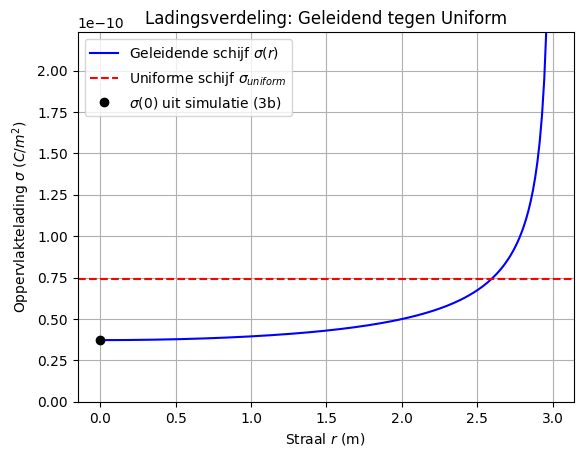

1. De berekende totale lading Q op de schijf is: 2.104e-09 C
2. De uniforme ladingsdichtheid is: 7.441e-11 C/m^2
   Ter vergelijking: de simulatie gaf in het midden: 3.720e-11 C/m^2
   Conclusie: De lading in het midden van de geleider is inderdaad precies de helft van de uniforme waarde.


In [16]:
# Calculate the total charge Q using the sigma from question 3b
Q_total = sigma * 2 * np.pi * disk_radius**2 

# Define the uniform charge density for comparison
sigma_uniform = Q_total / (np.pi * disk_radius**2)

# Create an array for r to plot the theoretical distribution
r_theory = np.linspace(0, disk_radius - 0.01, 200) 
sigma_conductor = Q_total / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_theory**2))

# Plotting the results
plt.figure()
plt.plot(r_theory, sigma_conductor, 'b-', label=r'Geleidende schijf $\sigma(r)$')
plt.axhline(sigma_uniform, color='r', linestyle='--', label=r'Uniforme schijf $\sigma_{uniform}$')
plt.plot(0, sigma, 'ko', label=r'$\sigma(0)$ uit simulatie (3b)')

plt.title("Ladingsverdeling: Geleidend tegen Uniform")
plt.xlabel("Straal $r$ (m)")
plt.ylabel(r"Oppervlaktelading $\sigma$ ($C/m^2$)")
plt.ylim(0, sigma_uniform * 3) # keep the scale readable
plt.legend()
plt.grid(True)
plt.show()

print("1. De berekende totale lading Q op de schijf is:", format(Q_total, '.3e'), "C")
print("2. De uniforme ladingsdichtheid is:", format(sigma_uniform, '.3e'), "C/m^2")
print("   Ter vergelijking: de simulatie gaf in het midden:", format(sigma, '.3e'), "C/m^2")
print("   Conclusie: De lading in het midden van de geleider is inderdaad precies de helft van de uniforme waarde.")

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [17]:
idx_max = np.argmax(normE) # finding the index of the maximum value in the electric field matrix
idx_z_max, idx_r_max = np.unravel_index(idx_max, normE.shape)

max_E = normE[idx_z_max, idx_r_max] # retrieving the maximum electric field value
r_max_pos = r_for_E[idx_r_max] # finding the radial position of the maximum
z_max_pos = z_for_E[idx_z_max] # finding the vertical position of the maximum

# E_buiten is already calculated in Question 3b
factor = max_E / E_buiten # calculating how many times the field is stronger at the edge compared to the center

print("1. Het maximale elektrische veld in de simulatie:", np.round(max_E, 2), "V/m")
print("2. De locatie van dit maximum: r =", np.round(r_max_pos, 1), "m en z =", np.round(z_max_pos, 1), "m")
print("3. Het veld bij de rand is", np.round(factor, 2), "keer zo sterk als in het midden.")

1. Het maximale elektrische veld in de simulatie: 11.75 V/m
2. De locatie van dit maximum: r = 3.0 m en z = 0.1 m
3. Het veld bij de rand is 2.8 keer zo sterk als in het midden.


##### Antwoord 3d.5

De oorzaak van dit lokaal hoge elektrische veld is dat ladingen in een geleider vrij kunnen bewegen en elkaar afstoten, waardoor ze zich zo ver mogelijk van elkaar vandaan proberen te nestelen. Omdat de rand van de schijf het uiterste punt is, verzamelt een groot deel van de lading zich daar, wat zorgt voor een hoge ladingsdichtheid bij r = 3 m. Omdat de sterkte van het elektrische veld direct afhangt van de lokale hoeveelheid lading, ontstaat er precies op die rand een ophoping waar het veld veel sterker is dan in het midden van de schijf.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

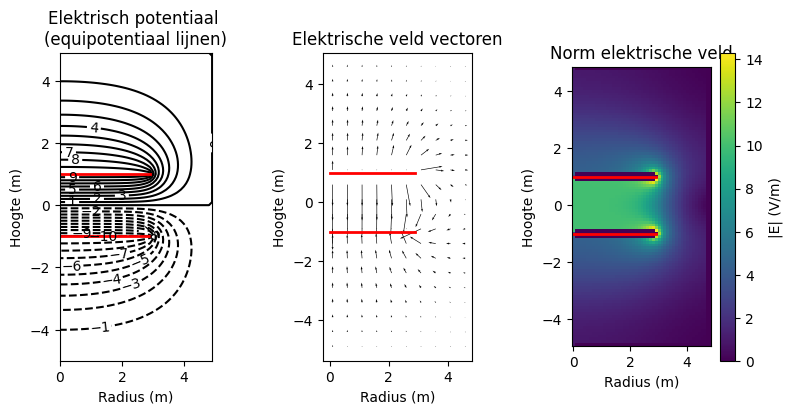

In [18]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


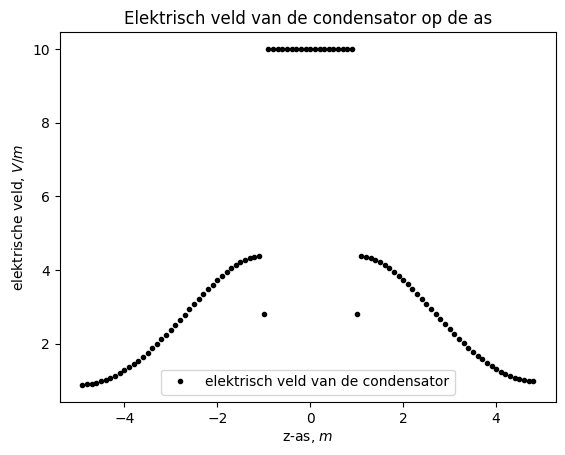

In [19]:
# Slicing the new normE for the central axis
E_as_condensator = normE[:, idx_R0] # slicing the norm of the e-field along the z-axis

plt.figure()
plt.plot(z_for_E, E_as_condensator, 'k.', label = "elektrisch veld van de condensator") # plotting with dots
plt.xlabel("z-as, $m$")
plt.ylabel("elektrische veld, $V/m$")
plt.title("Elektrisch veld van de condensator op de as")
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. Tussen de platen wordt een constant elektrisch veld verwacht. Met een potentiaalverschil $\Delta V = 20 \text{ V}$ en een afstand $d = 2 \text{ m}$ is de theoretische waarde $E = \frac{\Delta V}{d} = 10 \text{ V/m}$ in de regio $-1 < z < 1$. In de regio's buiten de platen ($|z| > 1$) is het veld voor een ideale condensator gelijk aan nul, omdat de veldbijdragen van de positieve en negatieve plaat elkaar daar opheffen.
2. In de plot is te zien dat het numerieke veld tussen de schijven inderdaad een horizontaal plateau vormt rond de $10 \text{ V/m}$, wat goed overeenkomt met de theorie. Vanaf de oppervlakken ($z = 1$ en $z = -1$) is te zien dat het elektrisch veld weer geleidelijk afneemt.
3. Vergeleken met de enkele schijf uit vraag 3a, waar het veld direct afnam naarmate $z$ groter werd, blijft het veld hier tussen de schijven juist constant. Het grote voordeel van deze configuratie is de creatie van een homogeen elektrisch veld. Hierdoor ondervindt een geladen deeltje overal tussen de platen een constante elektrische kracht, wat essentieel is voor nauwkeurige metingen met bepaalde deeltjes.


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
idx_z_midden = find_idx_nearest(z_for_E, 0)
E_midden = normE[idx_z_midden, idx_R0]


# Determining the expected surface charge on the inner side
sigma_binnen = epsilon0 * E_midden # using E = sigma / epsilon0 for the gap between plates

# Determining the expected total charge on the disks
Q_schijf = sigma_binnen * oppervlak # total expected charge magnitude on one disk

# Determining the capacitance of this situation
delta_V = V1 - V2 # potential difference between the positive and negative disk
capaciteit = Q_schijf / delta_V

# Printing the values in a neat manner
print("1. Oppervlaktelading op de binnenzijde: \t", format(sigma_binnen, '.3e'), "C/m^2")
print("2. Totale verwachte lading op de schijf (+Q en -Q):\t", format(Q_schijf, '.3e'), "C")
print("3. Capaciteit van deze opstelling: \t\t", format(capaciteit, '.3e'), "F")

1. Oppervlaktelading op de binnenzijde: 	 8.850e-11 C/m^2
2. Totale verwachte lading op de schijf (+Q en -Q):	 2.502e-09 C
3. Capaciteit van deze opstelling: 		 1.251e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. Nee, deze is niet gelijk aan nul. Hoewel de platen elkaar aantrekken en de meeste lading op de binnenzijde zit, is er op de buitenkant ook lading aanwezig. De schijven staan op een potentiaal van $10\text{ V}$ en $-10\text{ V}$, terwijl de rand van het domein $0\text{ V}$ is. Omdat er een potentiaalverschil is met de omgeving, loopt er een elektrisch veld van de buitenkant van de schijven naar de randen van het rekendomein. Volgens de wet van Gauss moet er op de plek waar een veldlijn vertrekt van een geleider altijd lading aanwezig zijn ($\sigma = \epsilon_0 E$).
2. Het elektrische veld vlakbij het oppervlak van een geleider staat altijd loodrecht op dat oppervlak. De theoretische waarde wordt beschreven door de formule $E = \frac{\sigma}{\epsilon_0}$. Hierbij is $\sigma$ de lokale oppervlakteladingsdichtheid en $\epsilon_0$ de vacuümpermittiviteit. Deze formule volgt direct uit de wet van Gauss. 

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [21]:
# Z-component of the electric field just below the bottom disk
idx_z_below = find_idx_nearest(z_for_E, z_pos_disk2 - grid_step) # index for position below the disk
Ez_below = Ez[idx_z_below, idx_R0] # retrieving Ez value below the disk

# Charge density on the bottom side of the bottom disk
sigma_bottom = -epsilon0 * Ez_below # calculating surface charge density using Gauss's law

# Z-component of the electric field just above the bottom disk
idx_z_above = find_idx_nearest(z_for_E, z_pos_disk2 + grid_step) # index for position above the disk
Ez_above = Ez[idx_z_above, idx_R0] # retrieving Ez value above the disk

# Charge density on the top side of the bottom disk
sigma_top = epsilon0 * Ez_above # calculating surface charge density using Gauss's law

# Printing the results in a clear overview
print("--- Bottom side of the bottom disk (-10V) ---")
print("1. Ez-component just below the disk: \t", np.round(Ez_below, 3), "V/m")
print("2. Surface charge density (bottom): \t", format(sigma_bottom, '.3e'), "C/m^2\n")

print("--- Top side of the bottom disk (-10V) ---")
print("3. Ez-component just above the disk: \t", np.round(Ez_above, 3), "V/m")
print("4. Surface charge density (top): \t", format(sigma_top, '.3e'), "C/m^2")

--- Bottom side of the bottom disk (-10V) ---
1. Ez-component just below the disk: 	 4.377 V/m
2. Surface charge density (bottom): 	 -3.875e-11 C/m^2

--- Top side of the bottom disk (-10V) ---
3. Ez-component just above the disk: 	 -10.004 V/m
4. Surface charge density (top): 	 -8.858e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. Uit vraag 4d en 4e kunnen we concluderen dat de daadwerkelijke lading op een schijf hoger is dan de waarde die we in 4c hebben berekend. In 4c hielden we alleen rekening met de lading op de binnenzijde ($Q = \sigma_{binnen} \cdot \text{oppervlak}$). De simulatie laat echter zien dat er ook een aanzienlijke hoeveelheid lading op de buitenkant van de schijven zit. Om de echte totale lading te vinden, moeten we de lading van beide kanten van de schijf bij elkaar optellen.
2. Omdat de werkelijke totale lading $Q$ hoger is dan we eerst aannamen, is de werkelijke capaciteit $C$ ook hoger. De formule $C = Q / \Delta V$ laat zien dat de capaciteit recht evenredig is met de totale opgeslagen lading bij een bepaald potentiaal. Door de "lekkende" lading aan de buitenkant te negeren, geeft de berekening in 4c dus een onderschatting van de werkelijke capaciteit van het systeem.
3. Wanneer de afstand tussen de schijven kleiner wordt gemaakt, wordt het elektrische veld tussen de platen veel sterker ($E \approx \Delta V / d$). Hierdoor gaat de lading zich nog meer concentreren op de binnenzijde door de sterkere aantrekkingskracht tussen de platen. Het resultaat is dat de totale lading $Q$ toeneemt, wat leidt tot een hogere capaciteit. In de simulatie zul je zien dat het plateau in de $E$-veld grafiek naar een hogere waarde verschuift.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [22]:
def vlakkeplaat(A, d, epsilon):
    C_plaat = (epsilon * epsilon0 * A) / d
    return C_plaat

def cilinder(a, b, L, epsilon):
    C_cilinder = (2 * np.pi * epsilon * epsilon0 * L) / np.log(b/a)
    return  C_cilinder


#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [23]:
epsilon_l = 1
epsilon_w = 80
epsilon_PVC = 3.5

#1:
A1 = .1 *.1 #m
d1 = .001 #m


print("capaciteit van een vlakkeplaat condensator", np.round(vlakkeplaat(A1, d1, epsilon_l), 14), "F")

#2: 
L2 = .1 #m
a2 = .009 / 2 #m
b2 = .01 / 2 #m

print("capaciteit van een cilinder condensator", np.round(cilinder(a2, b2, L2, epsilon_l), 15), "F")

#3:
print("verdubbelde afstand van de vlakkeplaat", np.round(vlakkeplaat(A1, d1, epsilon_l) / 2, 14), "F")
print("verdubbelde afstand van de cilinder", np.round(cilinder(a2, a2 + 2 * (b2 - a2), L2, epsilon_l), 15), "F")

#4:
print("capaciteit met water, vlakkeplaat condensator:", np.round(vlakkeplaat(A1, d1, epsilon_w), 12), "F")
print("capaciteit met water, verdubbelde vlakkeplaat condensator:", np.round(vlakkeplaat(A1, d1, epsilon_w) / 2, 12), "F")
print("capaciteit met water, cilinder condensator:", np.round(cilinder(a2, b2, L2, epsilon_w), 13), "F")
print("capaciteit met water, verdubbelde cilinder condensator:", np.round(cilinder(a2, a2 + 2 * (b2 - a2), L2, epsilon_w), 13), "F")

#5:
print("capaciteit met PVC, vlakkeplaat condensator:", np.round(vlakkeplaat(A1, d1, epsilon_PVC), 13), "F")
print("capaciteit met PVC, cilinder condensator:", np.round(cilinder(a2, b2, L2, epsilon_PVC), 14), "F")

capaciteit van een vlakkeplaat condensator 8.854e-11 F
capaciteit van een cilinder condensator 5.2801e-11 F
verdubbelde afstand van de vlakkeplaat 4.427e-11 F
verdubbelde afstand van de cilinder 2.7723e-11 F
capaciteit met water, vlakkeplaat condensator: 7.083e-09 F
capaciteit met water, verdubbelde vlakkeplaat condensator: 3.542e-09 F
capaciteit met water, cilinder condensator: 4.2241e-09 F
capaciteit met water, verdubbelde cilinder condensator: 2.2178e-09 F
capaciteit met PVC, vlakkeplaat condensator: 3.099e-10 F
capaciteit met PVC, cilinder condensator: 1.848e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [24]:
#im assuming that the dielectric constant is 5,000, theres two options for the type of ceramic used: X5R, y5V with the constant ranging form 2,000 - 10,000

epsilon_X5R = 10000
a = .005 / 2 #m
b = .006 / 2 #m
d = .0005 #m
w = .006 #m
capacitance = 1e-6 #Farad

L_capacitor = (capacitance * np.log(b/a)) / (2 * np.pi * epsilon0 * epsilon_X5R)

print("The estimated length of the capacitor is", np.round(L_capacitor, 3), "m")

L_plaat = (capacitance * d) / (epsilon0 * w * epsilon_X5R)

print("Required side length of square plates:", np.round(L_plaat, 3), "m")

The estimated length of the capacitor is 0.328 m
Required side length of square plates: 0.941 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. Nee deze antwoorden zijn niet realistisch. Als de afstand tussen de twee platen alleen 1mm en .5mm lijkt mij dat de capacitor niet heel groot is. Daarom vindt ik 30cm te groot.

2. Ze hebben vast de dielectric constant heel groot gemnaakt. Dus een materiaal gebruikt waarvan niet veel lading makkelijk doorheen kan. 

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [25]:
n_personen = 6
gewicht_per_persoon = 75 #kg
treintje_massa = 500 #kg
totale_massa = (n_personen * gewicht_per_persoon) + treintje_massa
v = 19.44 #m/s
voltage = 10e3 #kV
afstand = .001 #m

Energie = 0.5 * totale_massa * v**2

C = (2 * Energie) / (voltage)**2

A = C * afstand / (epsilon_w * epsilon0)

print("De totale energie die nodig is:", np.round(Energie), "Joules")
print("De capaciteit is", np.round(C, 5), "F")
print("De oppervlakte van de plaat is", np.round(A), "m^2")


De totale energie die nodig is: 179509.0 Joules
De capaciteit is 0.00359 F
De oppervlakte van de plaat is 5069.0 m^2


##### Antwoorden 5e

6. Nee, niet realistisch, want dan heb je dus een oppervlakte van meer van 5000 vierkante meter nodig. Je kan dit oplossen, door de plaat op te rollen, waardoor je veel meer vierkante meters kwijt kan in een klein volume.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

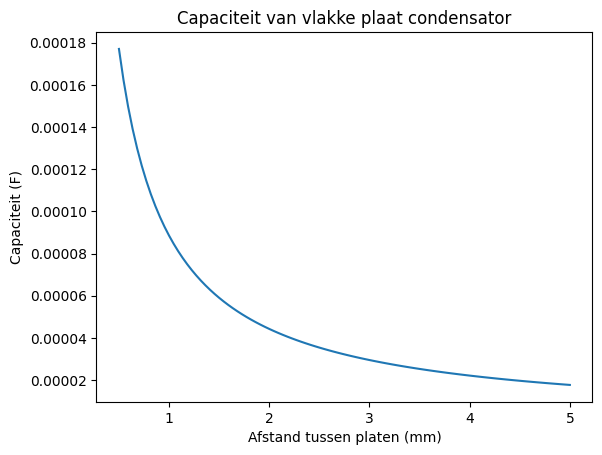

Text(0, 0.5, 'Capaciteit (pF)')

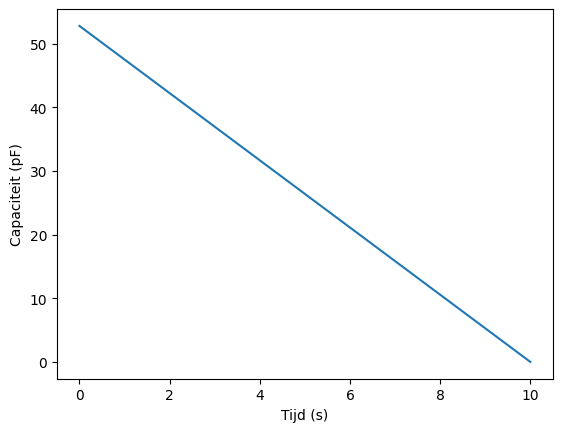

In [26]:
A = 0.1 * 0.1  # m²
d_values = np.linspace(0.0005, 0.005, 100)
C_plate = epsilon0 * epsilon_l * A / d_values

plt.plot(d_values*1000, C_plate*1e6)  # x in mm, C in mu F
plt.xlabel("Afstand tussen platen (mm)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit van vlakke plaat condensator")
plt.show()

Lengte = 0.1  # m
buiten = 0.01 / 2  # buitendiameter 10 mm
binnen_start = 0.009 / 2  # binnendiameter 9 mm
# Tijd 0-10 s
t = np.linspace(0, 10, 100)

C_cilinder = cilinder(binnen_start, buiten, Lengte * (1 - t/10), epsilon_l)


plt.plot(t, C_cilinder*1e12)
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (pF)")

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!

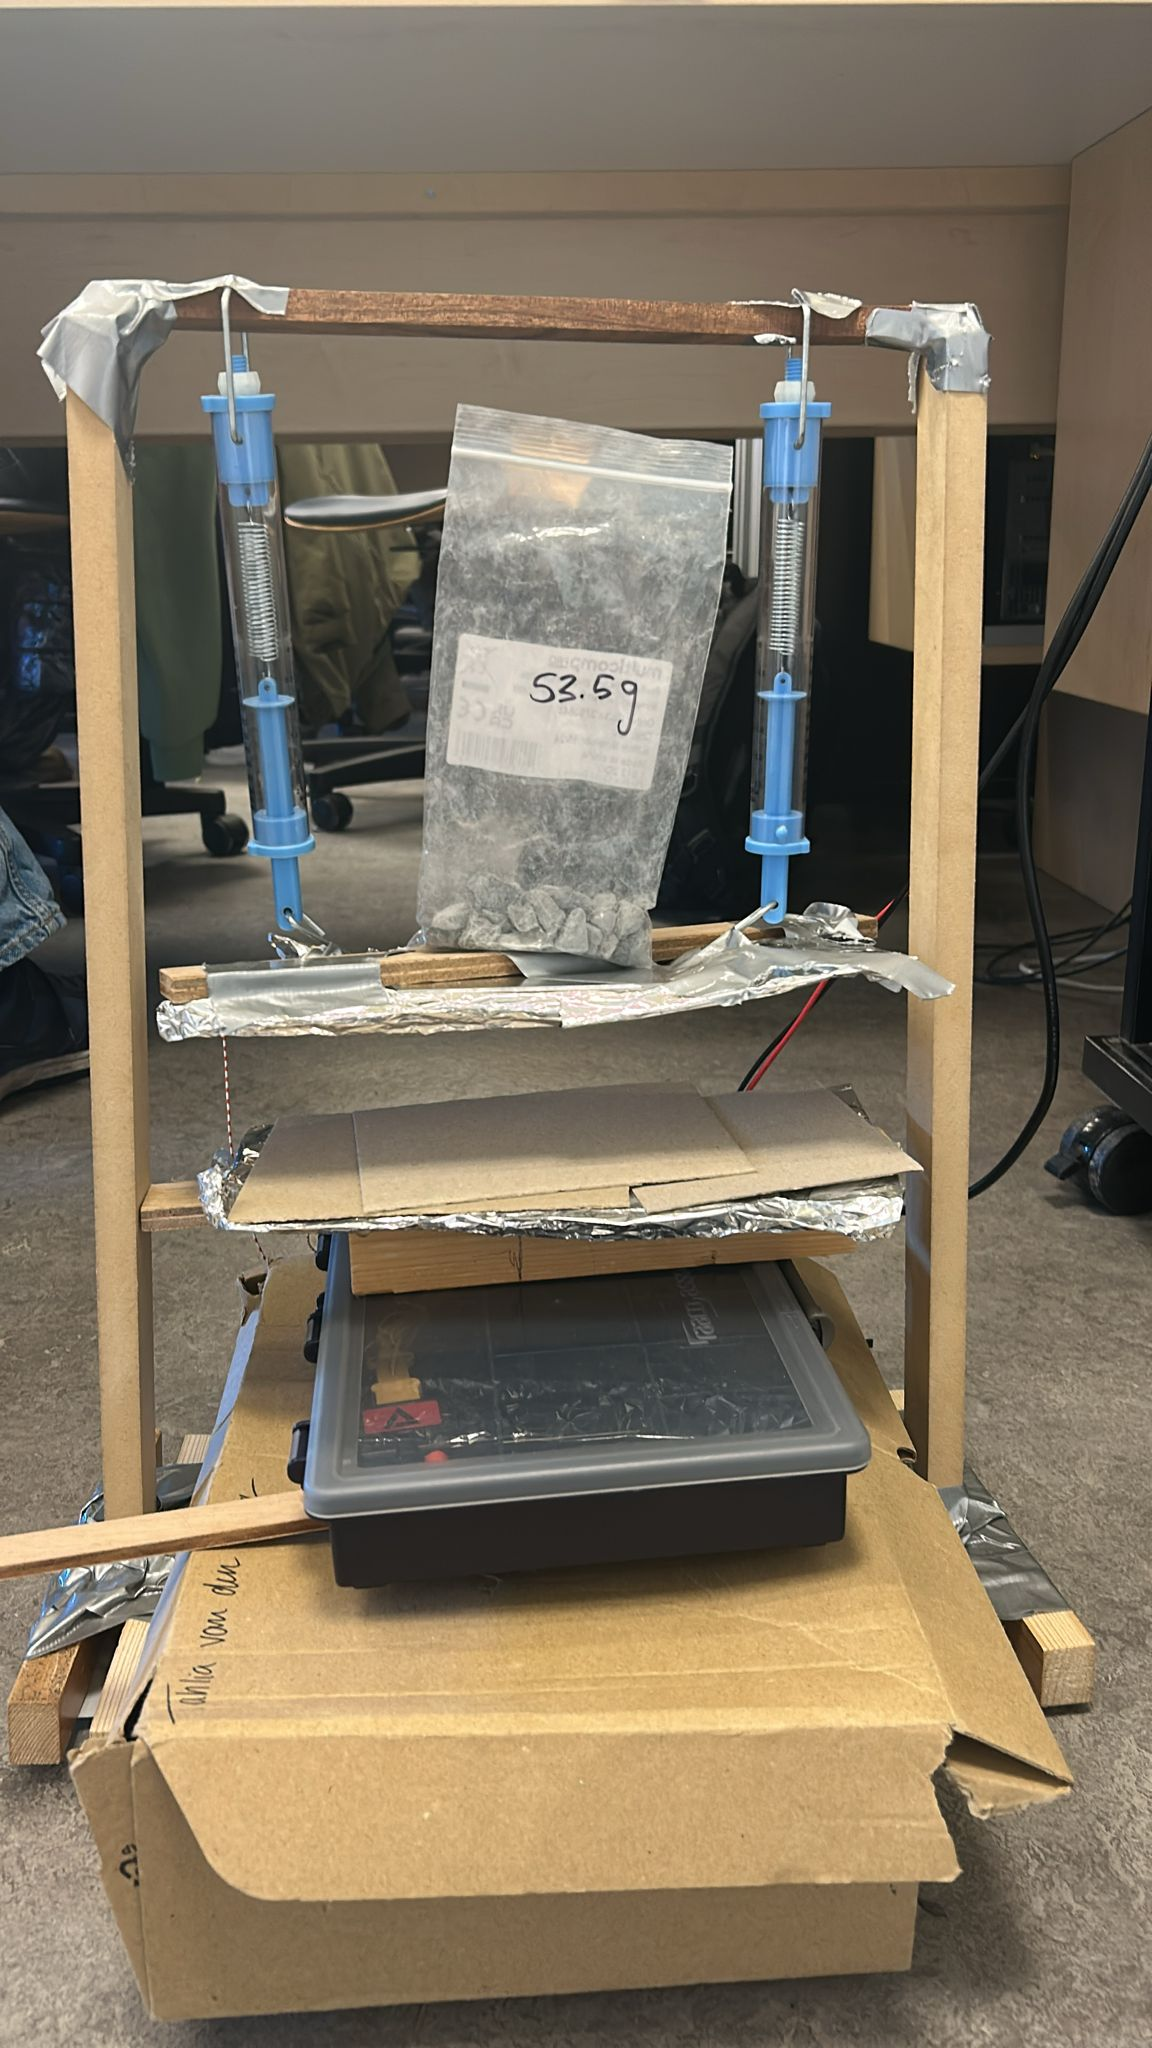

In [27]:
display(Image(filename='figures/opstelling_van_ontwerp.jpeg'))

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

$C = \frac{k \epsilon_0 A}{d}$
\
\
het dikte van de folie is: $d_{folie} = 0.001 m$
\
het dikte van de karton is: $d_{karton} = 0.003 m$
\
\
De afstand tussen de bovenste en onderste plaat is een functie van de gewicht:
\
\
$\alpha$ = veer gevoeligheid $\frac{meter}{gram}$
$D = D_0 - (\alpha)massa$
\
\
Elk heeft ook z'n eigen dielektrische constante:
\
\
$\epsilon_{karton} = 3.5$
$\epsilon_{folie} = 9.0$
$\epsilon_{lucht} = 1.0$
\
\
Dan is de nieuwe capaciteit vergelijking gecreeërt:
\
\
$C = \frac{\epsilon_0 A}{(\frac{D_0 - (\alpha)massa}{\epsilon})_{lucht} + (\frac{d}{\epsilon})_{karton} + (\frac{d}{\epsilon})_{folie}}$

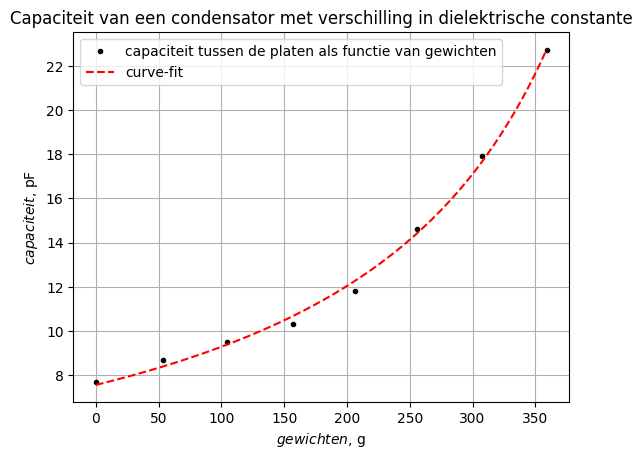

In [28]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies

gewichten = np.array([0, 53.5, 104.1, 157.1, 206.1, 255.5, 307.8, 359.2])  # gram
capaciteiten = np.array([7.7, 8.7, 9.5, 10.3, 11.8, 14.6, 17.9, 22.7])  # pF

l = 25/100 #meter
b = 14/100 #meter
epsilon_karton = 3.5
d_karton = 0.003 #meter
epsilon_folie = 9.0
d_folie = 0.001 #meter

def condensator_extra_laag(m, a):
    lucht = (0.040 - (m * a)) / epsilon_l
    karton = d_karton / epsilon_karton
    folie = d_folie / epsilon_folie
    C = epsilon0 * l * b / (lucht + karton + folie)
    return C *1e12 #pF

popt, pcov = curve_fit(condensator_extra_laag, gewichten, capaciteiten, p0 = 5e-6)

x = np.linspace(min(gewichten), max(gewichten), 1000)
y = condensator_extra_laag(x, popt)

### Maak hier je plot

plt.figure()
plt.plot(gewichten, capaciteiten, "k.", label = "capaciteit tussen de platen als functie van gewichten")
plt.plot(x, y, "r--", label = "curve-fit")
plt.xlabel("$gewichten$, g")
plt.ylabel("$capaciteit$, pF")
plt.title("Capaciteit van een condensator met verschilling in dielektrische constante")
plt.legend()
plt.grid(True)
plt.show()

##### Antwoorden 6a

Er is bijna geen verschil tussen de modellen. Dit komt omdat het folie en karton is niet dik genoeg, of geleident genoeg is om een groot verschil te maken ten opzichte van de lucht. Dit wordt voornamelijke veroorzaakt door de afstand tussen de platen. Met een korte evaluatie van de bijdragen van de verschillende materialen zien we dat lucht 97% bijdraagt aan de capaciteit. 
\
\
$\frac{d_{lucht}}{\epsilon_{lucht}} = 40 mm$
\
$\frac{d_{karton}}{\epsilon_{karton}} = 0.86 mm$
\
$\frac{d_{folie}}{\epsilon_{folie}} = 0.10 mm$
\
\
Door deze theoretische benadering kunnen we concluderen dat het laagje folie en karton bijvrijwel nul netto effect op het systeem hadden. Wel is het belangerijk op te merken, dat we beide lagen nodig hadden om stabiele metingen te kunnen uitvoeren bij een grote plaataftsand zoals $4cm$.Dit kan verklaard worden door stray capacitance, afkomstelijk van nabijgelegen objecten, bijvoorbeeld de draatjes of onze laptops. Dit werd duidelijk zichtbaar toen de Arduino nog op de platen verbonden was en we deze aanraakte. De bits schoten omhoog. Mijn theorie is wanneer we een materiaal op de platen leggen kregen wij de mogelijkheid om meer ladingen op de "nieuwe plaat"toe te voegen. Dat betekent dat heel veel van de edge effect ineffectief word door sterkere veld lijnen. 

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [29]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [30]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Wij hadden meerdere verschillen tussen de uiteindelijke capaciteiten. In de eerste berekening hadden wij de enkele waarden van 22 pF. Dit komt overeen met onze laatste meting van 22.7 pF toen de weegschaal helemaal naar beneden was gedrukt. 
\
\
In opdracht 4 hadden wij een array van variërende capaciteiten gemeten, ook als een functie van gewichten die de afstand tussen de twee platen verkleinde. Dit kwam in een range van 2 tot en met 12 pF. Zoals wij in opdracht 6 gezien hebben, is de meest effectieve variable de afstand tussen de twee platen. In de voorspelde kalibratiegrafiek is deze initiële afstand als $1.5cm$ gezet. Dit verschilt veel van de werkelijke $4cm$ afstand zonder gewicht. 
\
\
Deze afwijkingen kunnen met meerderdeel verklaard worden door die afstand. Afgezien daarvan waren onze voorspelllingen best accuraat. 